### User Classification 

#### Importing Required Libraries


In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

#### Reading Data

In [2]:
articles = pd.read_csv("data/news_articles.csv")

In [3]:
df = pd.read_csv("data/train_users.csv")

In [4]:
df.head()

,user_id,age,income,clicks,purchase_amount,session_duration,content_variety,engagement_score,num_transactions,avg_monthly_spend,...,screen_brightness,battery_percentage,cart_abandonment_count,browser_version,background_app_count,session_inactivity_duration,network_jitter,region_code,subscriber,label
0,U7392,NaN,23053,10,500.00,17.34,0.36661,37.29781,3,187.44,...,4.0,2.0,8,3.17.97,10,22.75,8.0,Z999,False,user_3
1,U2702,56.0,20239,11,913.33,22.22,0.61370,59.36342,5,145.15,...,4.5,63.0,5,1.57.10,8,1.75,4.0,U428,True,user_2
2,U2461,NaN,13907,9,1252.62,41.57,0.80368,76.78706,7,282.03,...,1.3,22.0,2,2.16.94,12,29.33,18.0,Z999,True,user_3
3,U7475,NaN,26615,12,500.00,30.17,0.26499,30.19441,10,195.35,...,4.2,77.0,9,9.90.20,4,21.61,22.0,X123,False,user_3
4,U6040,32.0,27958,13,500.00,65.27,0.36385,37.12153,5,439.68,...,4.6,30.0,9,1.99.38,7,7.58,52.0,S043,False,user_1


In [5]:
X = df.drop(columns=['label', 'user_id'])
y = df['label']


#### Preprocessing

In [6]:
X['subscriber'] = X['subscriber'].astype(int)


In [7]:
imputer = SimpleImputer(strategy='median')
X['age'] = imputer.fit_transform(X[['age']])


In [8]:
X = pd.get_dummies(
    X,
    columns=['browser_version', 'region_code'],
    drop_first=True
)


In [9]:
X.head()

,age,income,clicks,purchase_amount,session_duration,content_variety,engagement_score,num_transactions,avg_monthly_spend,avg_cart_value,...,region_code_Z779,region_code_Z795,region_code_Z797,region_code_Z852,region_code_Z873,region_code_Z894,region_code_Z913,region_code_Z925,region_code_Z985,region_code_Z999
0,39.0,23053,10,500.00,17.34,0.36661,37.29781,3,187.44,119.61,...,False,False,False,False,False,False,False,False,False,True
1,56.0,20239,11,913.33,22.22,0.61370,59.36342,5,145.15,189.06,...,False,False,False,False,False,False,False,False,False,False
2,39.0,13907,9,1252.62,41.57,0.80368,76.78706,7,282.03,161.75,...,False,False,False,False,False,False,False,False,False,True
3,39.0,26615,12,500.00,30.17,0.26499,30.19441,10,195.35,23.91,...,False,False,False,False,False,False,False,False,False,False
4,32.0,27958,13,500.00,65.27,0.36385,37.12153,5,439.68,57.68,...,False,False,False,False,False,False,False,False,False,False


In [10]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)


#### Train Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)


#### Standardization

In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


#### Model Fitting

In [13]:
clf_2 = LogisticRegression(
    penalty='l1',
    solver='saga',
    C=0.5,
    max_iter=1000,
    multi_class='multinomial'
)
clf_2.fit(X_train_scaled, y_train)

e:\anaconda_files\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
e:\anaconda_files\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(C=0.5, max_iter=1000, multi_class='multinomial',
                   penalty='l1', solver='saga')

#### Prediction

In [14]:
y_pred = clf_2.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.925
              precision    recall  f1-score   support

           0       0.91      0.88      0.89       142
           1       0.99      0.91      0.95       142
           2       0.88      1.00      0.94       116

    accuracy                           0.93       400
   macro avg       0.93      0.93      0.93       400
weighted avg       0.93      0.93      0.92       400



####  Contextual Bandit Algorithms

In [15]:
news_categories = ["Entertainment", "Education", "Tech", "Crime"]

def get_arm_index(user_context, news_category):
    context_offset = {
        "User1": 0,
        "User2": 4,
        "User3": 8
    }
    return context_offset[user_context] + news_categories.index(news_category)

get_arm_index('User1', 'Education')

1

In [16]:
from rlcmab_sampler import sampler

ROLL_NUMBER = 94 # id
reward_sampler = sampler(ROLL_NUMBER)

 ##### Epsilon-Greedy 

In [17]:
import numpy as np

contexts = ["User1", "User2", "User3"]
n_arms = 4
Q = {c: np.zeros(n_arms) for c in contexts}
N = {c: np.zeros(n_arms) for c in contexts}

In [18]:
import random

def epsilon_greedy(context, epsilon, Q):
    if random.random() < epsilon:
        return random.randint(0, n_arms - 1)
    return np.argmax(Q[context])

In [22]:
def train_epsilon_greedy(epsilon, T=10000):
    rewards_over_time = []
    Q = {c: np.zeros(n_arms) for c in contexts}
    N = {c: np.zeros(n_arms) for c in contexts}

    for t in range(T):
        context = random.choice(contexts)
        arm = epsilon_greedy(context, epsilon, Q)

        global_arm = get_arm_index(context, news_categories[arm])
        reward = reward_sampler.sample(global_arm)

        N[context][arm] += 1
        Q[context][arm] += (reward - Q[context][arm]) / N[context][arm]

        rewards_over_time.append(reward)
    return np.cumsum(rewards_over_time) / np.arange(1, T + 1), Q, N

In [23]:
epsilons = [1, 0.01, 0.05, 0.1, 0.3]
epsilon_results = {}

for eps in epsilons:
    epsilon_results[eps], Q, N = train_epsilon_greedy(eps)

Epsilon-Greedy Performance
Best epsilon:  0.01


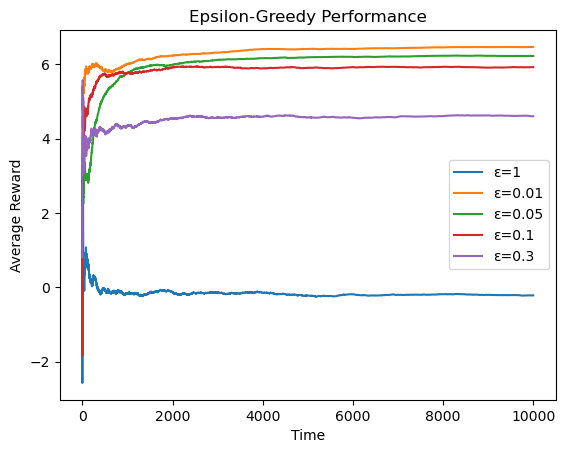

In [24]:
epsilons = [1, 0.01, 0.05, 0.1, 0.3]
epsilon_results = {}
for eps in epsilons:
    epsilon_results[eps], Q, N = train_epsilon_greedy(eps)

final_rewards = [epsilon_results[eps][-1] for eps in epsilons]

best_eps = epsilons[final_rewards.index(max(final_rewards))]

print("Epsilon-Greedy Performance")
print('Best epsilon: ', best_eps)
import matplotlib.pyplot as plt

for eps, rewards in epsilon_results.items():
    plt.plot(rewards, label=f"ε={eps}")
plt.xlabel("Time")
plt.ylabel("Average Reward")
plt.title("Epsilon-Greedy Performance")
plt.legend()
plt.show()


EPSILON-GREEDY: AVERAGE REWARD BY CONTEXT


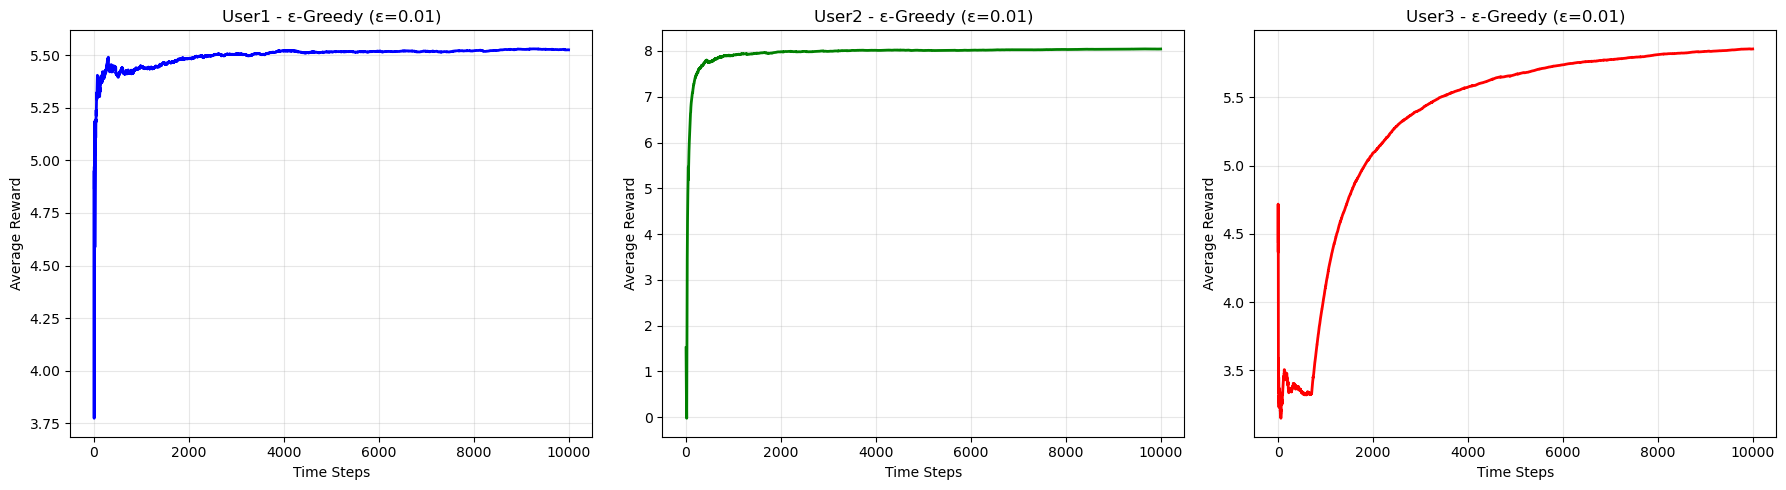

In [ ]:
# Plot Average Reward vs Time for Each Context (Epsilon-Greedy)
print("\n" + "="*70)
print("EPSILON-GREEDY: AVERAGE REWARD BY CONTEXT")
print("="*70)


def train_epsilon_greedy_per_context(epsilon, T=10000):
    context_rewards = {c: [] for c in contexts}
    Q = {c: np.zeros(n_arms) for c in contexts}
    N = {c: np.zeros(n_arms) for c in contexts}
    
    for context in contexts:
        for t in range(T):
            arm = epsilon_greedy(context, epsilon, Q)
            
            global_arm = get_arm_index(context, news_categories[arm])
            reward = reward_sampler.sample(global_arm)
            
            N[context][arm] += 1
            Q[context][arm] += (reward - Q[context][arm]) / N[context][arm]
            
            context_rewards[context].append(reward)
    
    avg_rewards_per_context = {}
    for context in contexts:
        rewards = context_rewards[context]
        avg_rewards_per_context[context] = np.cumsum(rewards) / np.arange(1, len(rewards) + 1)
    
    return avg_rewards_per_context, Q, N

# Train with best epsilon
context_rewards_eps, _, _ = train_epsilon_greedy_per_context(best_eps)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = {'User1': 'blue', 'User2': 'green', 'User3': 'red'}

for idx, context in enumerate(contexts):
    if len(context_rewards_eps[context]) > 0:
        axes[idx].plot(context_rewards_eps[context], color=colors[context], linewidth=2)
        axes[idx].set_xlabel('Time Steps')
        axes[idx].set_ylabel('Average Reward')
        axes[idx].set_title(f'{context} - ε-Greedy (ε={best_eps})')
        axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Upper Confidence Bound (UCB)

In [ ]:
# Cell: UCB Implementation
import numpy as np
import random

def ucb(context, c, Q, N, t):
    ucb_values = np.zeros(n_arms)
    
    for arm in range(n_arms):
        if N[context][arm] == 0:
            return arm
        
        exploitation = Q[context][arm]
        exploration = c * np.sqrt(np.log(t + 1) / N[context][arm])
        ucb_values[arm] = exploitation + exploration
    
    return np.argmax(ucb_values)


def train_ucb(c, T=10000):
    rewards_over_time = []
    Q = {context: np.zeros(n_arms) for context in contexts}
    N = {context: np.zeros(n_arms) for context in contexts}
    
    for t in range(T):
        context = random.choice(contexts)
        arm = ucb(context, c, Q, N, t)
        
        # Get global arm index and sample reward
        global_arm = get_arm_index(context, news_categories[arm])
        reward = reward_sampler.sample(global_arm)
        
        N[context][arm] += 1
        Q[context][arm] += (reward - Q[context][arm]) / N[context][arm]
        
        rewards_over_time.append(reward)
    
    return np.cumsum(rewards_over_time) / np.arange(1, T + 1), Q, N

UCB Performance
Best C: 2


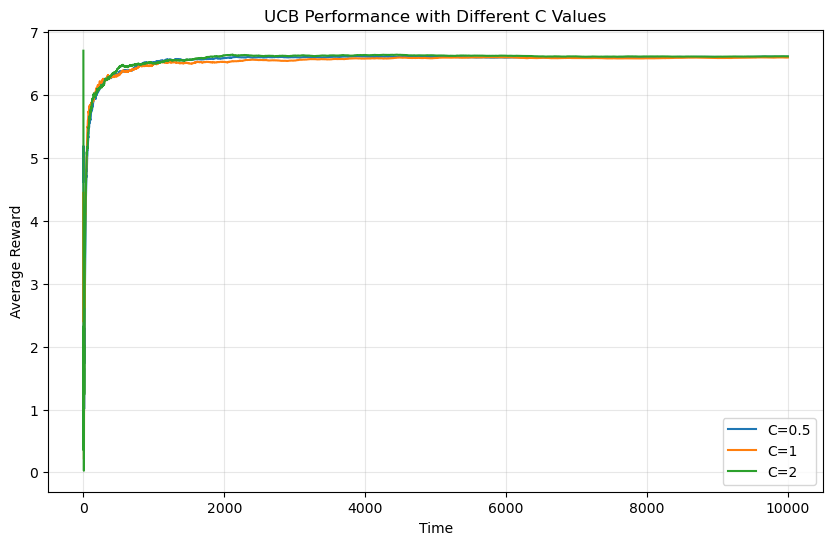

In [35]:
# Cell: Test UCB with different C values
c_values = [0.5, 1 ,2]
ucb_results = {}

for c in c_values:
    avg_rewards, Q_final, N_final = train_ucb(c)
    ucb_results[c] = avg_rewards

print("UCB Performance")
final_avg_rewards = [i[-1] for i in ucb_results.values()]
best_c = c_values[final_avg_rewards.index(max(final_avg_rewards))]
print(f"Best C: {best_c}")

# Plot results
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
for c, rewards in ucb_results.items():
    plt.plot(rewards, label=f"C={c}")

plt.xlabel("Time")
plt.ylabel("Average Reward")
plt.title("UCB Performance with Different C Values")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


UCB: AVERAGE REWARD BY CONTEXT


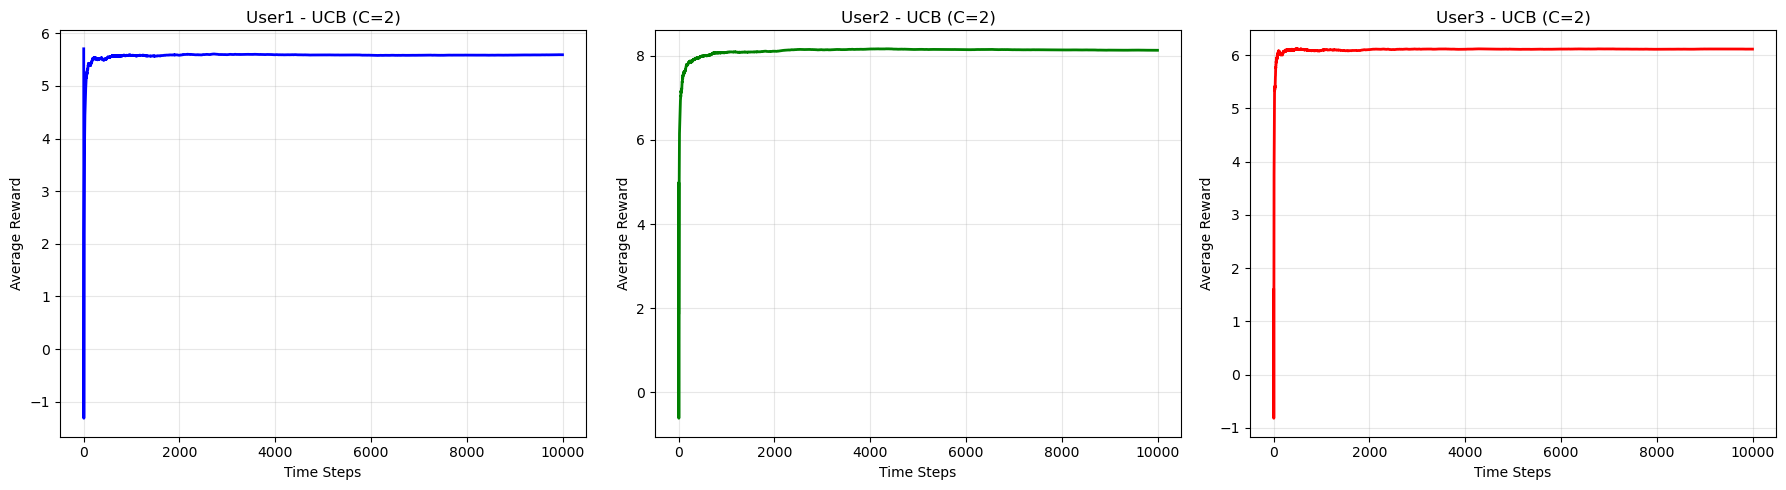

In [36]:
# Plot Average Reward vs Time for Each Context (UCB)
print("\n" + "="*70)
print("UCB: AVERAGE REWARD BY CONTEXT")
print("="*70)

# Retrain with best C but track per-context rewards
def train_ucb_per_context(c, T=10000):
    context_rewards = {ctx: [] for ctx in contexts}
    Q = {ctx: np.zeros(n_arms) for ctx in contexts}
    N = {ctx: np.zeros(n_arms) for ctx in contexts}

    for t in range(1, T + 1):
        for context in contexts:
            arm = ucb(context, c, Q, N, t)

            global_arm = get_arm_index(context, news_categories[arm])
            reward = reward_sampler.sample(global_arm)

            N[context][arm] += 1
            Q[context][arm] += (reward - Q[context][arm]) / N[context][arm]

            context_rewards[context].append(reward)
    
    # Calculate cumulative average for each context
    avg_rewards_per_context = {}
    for context in contexts:
        rewards = context_rewards[context]
        if len(rewards) > 0:
            avg_rewards_per_context[context] = np.cumsum(rewards) / np.arange(1, len(rewards) + 1)
        else:
            avg_rewards_per_context[context] = []
    
    return avg_rewards_per_context, Q, N

# Train with best C
context_rewards_ucb, _, _ = train_ucb_per_context(best_c)

# Plot separate graphs for each context
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = {'User1': 'blue', 'User2': 'green', 'User3': 'red'}

for idx, context in enumerate(contexts):
    if len(context_rewards_ucb[context]) > 0:
        axes[idx].plot(context_rewards_ucb[context], color=colors[context], linewidth=2)
        axes[idx].set_xlabel('Time Steps')
        axes[idx].set_ylabel('Average Reward')
        axes[idx].set_title(f'{context} - UCB (C={best_c})')
        axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

####  SoftMax

In [37]:
# Cell: SoftMax Implementation
import numpy as np
import random

def softmax(context, tau, Q):

    # Calculate softmax probabilities
    q_values = Q[context]
    exp_values = np.exp(q_values / tau)
    probabilities = exp_values / np.sum(exp_values)
    
    # Sample arm according to probabilities
    arm = np.random.choice(n_arms, p=probabilities)
    return arm


def train_softmax(tau=1.0, T=10000):
    rewards_over_time = []
    Q = {context: np.zeros(n_arms) for context in contexts}
    N = {context: np.zeros(n_arms) for context in contexts}
    
    for t in range(T):
        arm = softmax(context, tau, Q)
        
        # Get global arm index and sample reward
        global_arm = get_arm_index(context, news_categories[arm])
        reward = reward_sampler.sample(global_arm)
        
        # Update Q and N
        N[context][arm] += 1
        Q[context][arm] += (reward - Q[context][arm]) / N[context][arm]
        
        rewards_over_time.append(reward)
    
    return np.cumsum(rewards_over_time) / np.arange(1, T + 1), Q, N

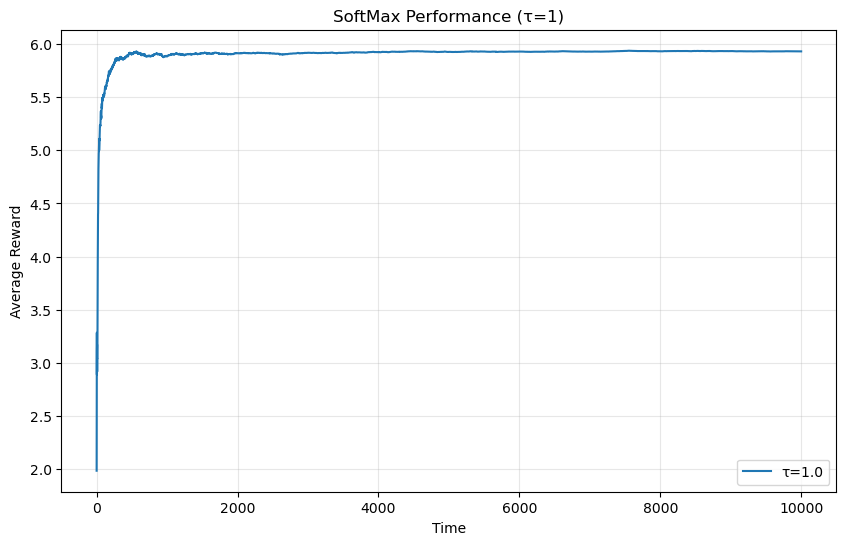

In [42]:
# Cell: Test SoftMax (tau=1 as per assignment)
tau = 1.0
softmax_avg_rewards, softmax_Q, softmax_N = train_softmax(tau=tau)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(softmax_avg_rewards, label=f"τ={tau}")
plt.xlabel("Time")
plt.ylabel("Average Reward")
plt.title("SoftMax Performance (τ=1)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


SOFTMAX: AVERAGE REWARD BY CONTEXT


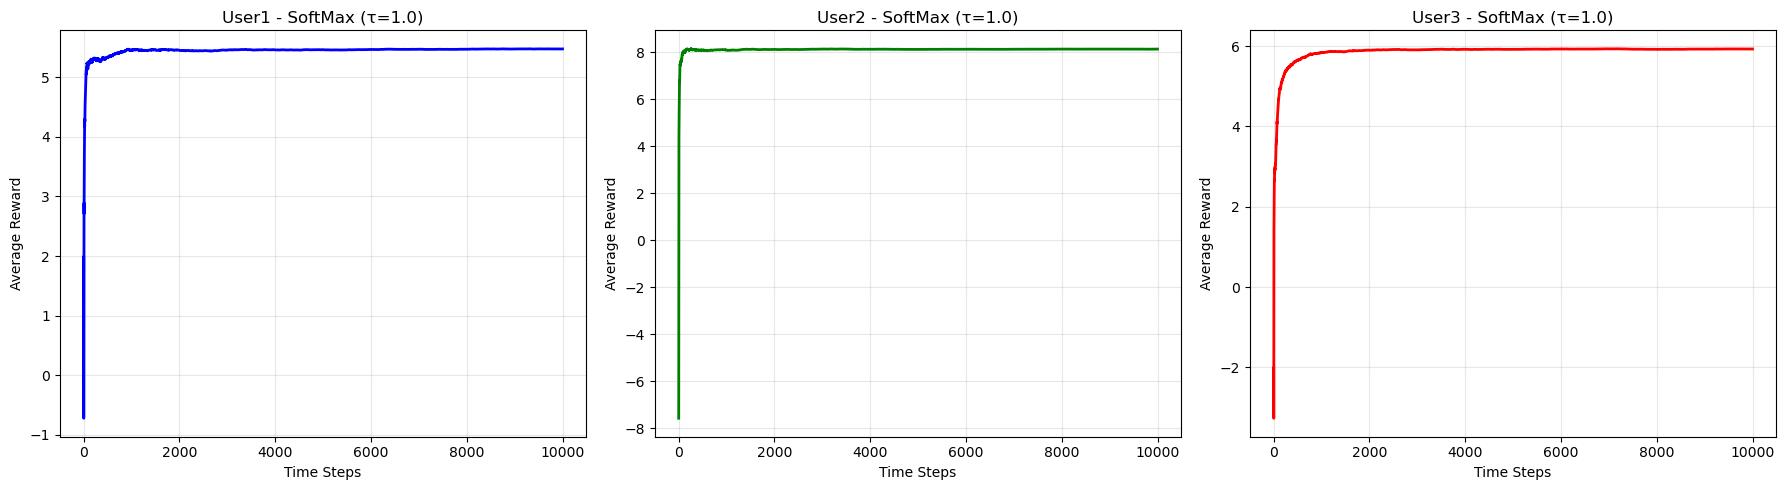

In [43]:
# Plot Average Reward vs Time for Each Context (SoftMax)
print("\n" + "="*70)
print("SOFTMAX: AVERAGE REWARD BY CONTEXT")
print("="*70)

def train_softmax_per_context(tau=1.0, T=10000):
    context_rewards = {ctx: [] for ctx in contexts}
    Q = {ctx: np.zeros(n_arms) for ctx in contexts}
    N = {ctx: np.zeros(n_arms) for ctx in contexts}

    for t in range(T):
        for context in contexts:
            arm = softmax(context, tau, Q)

            global_arm = get_arm_index(context, news_categories[arm])
            reward = reward_sampler.sample(global_arm)

            N[context][arm] += 1
            Q[context][arm] += (reward - Q[context][arm]) / N[context][arm]

            context_rewards[context].append(reward)
    
    avg_rewards_per_context = {}
    for context in contexts:
        rewards = context_rewards[context]
        if len(rewards) > 0:
            avg_rewards_per_context[context] = np.cumsum(rewards) / np.arange(1, len(rewards) + 1)
        else:
            avg_rewards_per_context[context] = []
    
    return avg_rewards_per_context, Q, N

context_rewards_softmax, _, _ = train_softmax_per_context(tau)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = {'User1': 'blue', 'User2': 'green', 'User3': 'red'}

for idx, context in enumerate(contexts):
    if len(context_rewards_softmax[context]) > 0:
        axes[idx].plot(context_rewards_softmax[context], color=colors[context], linewidth=2)
        axes[idx].set_xlabel('Time Steps')
        axes[idx].set_ylabel('Average Reward')
        axes[idx].set_title(f'{context} - SoftMax (τ={tau})')
        axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Performance Comparison


Algorithm Configuration   | Final Avg Reward
---------------------------------------------
ε-Greedy (ε=0.01)         | 6.470142        
UCB (C=2)                 | 6.615788        WINNER
SoftMax (τ=1.0)           | 5.930877        


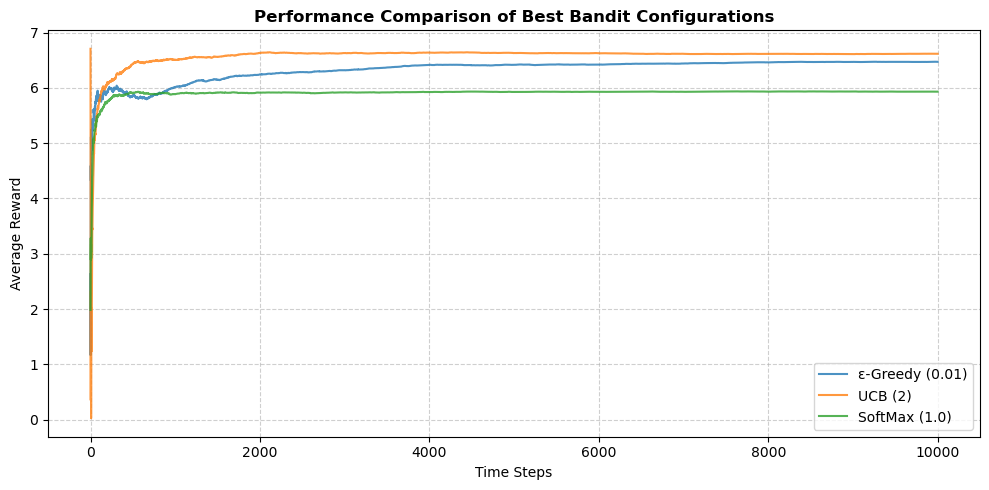


 Selecting UCB (C=2) Q-values for the recommendation engine...


In [45]:
best_eps = max(epsilon_results, key=lambda k: epsilon_results[k][-1])
best_c = max(ucb_results, key=lambda k: ucb_results[k][-1])

comparison = {
    f"ε-Greedy (ε={best_eps})": epsilon_results[best_eps][-1],
    f"UCB (C={best_c})": ucb_results[best_c][-1],
    f"SoftMax (τ={tau})": softmax_avg_rewards[-1]
}
winner = max(comparison, key=comparison.get)

# 3. Print Compact Results Table
print(f"\n{'Algorithm Configuration':<25} | {'Final Avg Reward':<15}")
print("-" * 45)
for algo, reward in comparison.items():
    marker = "WINNER" if algo == winner else ""
    print(f"{algo:<25} | {reward:<15.6f} {marker}")

# 4. Streamlined Plotting
plt.figure(figsize=(10, 5))
plt.plot(epsilon_results[best_eps], label=f"ε-Greedy ({best_eps})", alpha=0.8)
plt.plot(ucb_results[best_c], label=f"UCB ({best_c})", alpha=0.8)
plt.plot(softmax_avg_rewards, label=f"SoftMax ({tau})", alpha=0.8)

plt.title("Performance Comparison of Best Bandit Configurations", fontweight='bold')
plt.xlabel("Time Steps")
plt.ylabel("Average Reward")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 5. Extract Best Q-values for Recommendation Engine
print(f"\n Selecting {winner} Q-values for the recommendation engine...")
if "ε-Greedy" in winner:
    _, best_Q, _ = train_epsilon_greedy(best_eps)
elif "UCB" in winner:
    _, best_Q, _ = train_ucb(best_c)
else:
    best_Q = softmax_Q

Preprocessing test_users

In [ ]:
df_test = pd.read_csv("data/test_users.csv")

test_user_ids = df_test['user_id'].copy()

X_new = df_test.drop(columns=['user_id'])

X_new['subscriber'] = X_new['subscriber'].astype(int)


X_new['age'] = imputer.transform(X_new[['age']])

X_new = pd.get_dummies(
    X_new,
    columns=['browser_version', 'region_code'],
    drop_first=True
)

X_new = X_new.reindex(columns=X_train.columns, fill_value=0)

X_new_scaled = scaler.transform(X_new)


In [ ]:
print("News Articles Columns:", articles.columns.tolist())
print("\nUnique categories in news:", articles['category'].unique())
print("\nSample news article:")
print(articles.iloc[0])
print("\nCategory counts:")
print(articles['category'].value_counts())

News Articles Columns: ['link', 'headline', 'category', 'short_description', 'authors', 'date']

Unique categories in news: ['U.S. NEWS' 'COMEDY' 'PARENTING' 'WORLD NEWS' 'CULTURE & ARTS' 'TECH'
 'SPORTS' 'ENTERTAINMENT' 'POLITICS' 'WEIRD NEWS' 'ENVIRONMENT'
 'EDUCATION' 'CRIME' 'SCIENCE' 'WELLNESS' 'BUSINESS' 'STYLE & BEAUTY'
 'FOOD & DRINK' 'MEDIA' 'QUEER VOICES' 'HOME & LIVING' 'WOMEN'
 'BLACK VOICES' 'TRAVEL' 'MONEY' 'RELIGION' 'LATINO VOICES' 'IMPACT'
 'WEDDINGS' 'COLLEGE' 'PARENTS' 'ARTS & CULTURE' 'STYLE' 'GREEN' 'TASTE'
 'HEALTHY LIVING' 'THE WORLDPOST' 'GOOD NEWS' 'WORLDPOST' 'FIFTY' 'ARTS'
 'DIVORCE']

Sample news article:
link                 https://www.huffpost.com/entry/covid-boosters-...
headline             Over 4 Million Americans Roll Up Sleeves For O...
category                                                     U.S. NEWS
short_description    Health experts said it is too early to predict...
authors                                           Carla K. Johnson, AP
date

#### Recommendation Engine

In [52]:
# Cell: Simple Recommendation System
def recommend_article(user_features_scaled, user_id):
    user_category_encoded = clf_2.predict(user_features_scaled.reshape(1, -1))[0]
    user_category_label = le.inverse_transform([user_category_encoded])[0]
    

    context_mapping = {
        'user_1': 'User1',
        'user_2': 'User2',
        'user_3': 'User3'
    }
    context = context_mapping[user_category_label]
    

    best_arm = np.argmax(best_Q[context])
    news_category = news_categories[best_arm]
    

    category_articles = articles[articles['category'].str.lower() == news_category.lower()]
    
    if len(category_articles) > 0:
        sampled_article = category_articles.sample(n=1).iloc[0]
        article_title = sampled_article['headline']  
        article_id = sampled_article.name
    else:
        article_title = "No article available"
        article_id = None
    
    return {
        'user_id': user_id,
        'user_category': user_category_label,
        'context': context,
        'recommended_category': news_category,
        'arm_index': best_arm,
        'article_title': article_title,
        'article_id': article_id
    }


sample_rec = recommend_article(X_new_scaled[0], test_user_ids.iloc[0])
print("Sample Recommendation:")
print(f"  User ID: {sample_rec['user_id']}")
print(f"  Predicted Category: {sample_rec['user_category']}")
print(f"  Recommended News: {sample_rec['recommended_category']}")
print(f"  Article: {sample_rec['article_title'][:80]}...")

Sample Recommendation:
  User ID: U4058
  Predicted Category: user_3
  Recommended News: Crime
  Article: Teen Clogs Up 911 Lines In ‘Dangerous’ Twitter Stunt...


In [54]:
print("="*70)
print("GENERATING RECOMMENDATIONS FOR ALL TEST USERS")
print("="*70)

all_recommendations = []

for i in range(len(X_new_scaled)):
    rec = recommend_article(X_new_scaled[i], test_user_ids.iloc[i])
    all_recommendations.append(rec)

print(f"\n✓ Generated {len(all_recommendations)} recommendations")

recommendations_df = pd.DataFrame(all_recommendations)

output_df = recommendations_df[['user_id', 'user_category', 'recommended_category', 'article_title']].copy()
output_df.columns = ['User ID', 'Predicted User Category', 'Recommended News Category', 'Recommended Article']

print("\n" + "="*70)
print("FINAL RECOMMENDATIONS OUTPUT")
print("="*70)
print(output_df.head(10))

output_df.to_csv('final_recommendations.csv', index=False)

print("\n" + "="*70)
print("SUMMARY STATISTICS")
print("="*70)

print("\nPredicted User Categories Distribution:")
print(recommendations_df['user_category'].value_counts())

print("\nRecommended News Categories Distribution:")
print(recommendations_df['recommended_category'].value_counts())

print("\n" + "="*70)
print("ARTICLES RECOMMENDED PER USER COHORT")
print("="*70)
cross_tab = pd.crosstab(
    recommendations_df['user_category'], 
    recommendations_df['recommended_category'],
    margins=True,
    margins_name='Total'
)
print("\n", cross_tab)

GENERATING RECOMMENDATIONS FOR ALL TEST USERS

✓ Generated 2000 recommendations

FINAL RECOMMENDATIONS OUTPUT
  User ID Predicted User Category Recommended News Category  \
0   U4058                  user_3                     Crime   
1   U1118                  user_1             Entertainment   
2   U6555                  user_1             Entertainment   
3   U9170                  user_1             Entertainment   
4   U3348                  user_1             Entertainment   
5   U2244                  user_3                     Crime   
6   U3022                  user_3                     Crime   
7   U5291                  user_1             Entertainment   
8   U1945                  user_3                     Crime   
9   U6084                  user_3                     Crime   

                                 Recommended Article  
0  Prisoner Takes Down Fellow Inmate During Vicio...  
1  Gwyneth Paltrow Shines In Mermaid Dress At Env...  
2  Laverne Cox Wants To Reframe